<a href="https://colab.research.google.com/github/LeoSuzu/Bitcoin_Analysis_And_Prediction/blob/main/Bitcoin_Price_Analysis_5y_retrospective/bitcoin_analysis_5y.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bitcoin Price Analysis: A 5-Year Retrospective
## Comparing Market Value with Global Search Trends

**Author:** Leo Suzuki  
**Institution:** Tampere University of Applied Sciences  
**Year:** 2026  

---

### 🚀 How to Run This Project

This notebook is designed to run automatically without requiring any manual data downloads, CSV files, or Google Drive mounting.

#### 1. Install Required Libraries
Ensure the first code cell is executed before running the rest of the script. This installs the necessary APIs for fetching live data:

python
!pip install yfinance pytrends

#### 2. Execute the Code
Simply run the remaining cells from top to bottom.

**What happens automatically behind the scenes:**
* **Dynamic Timeframe:** The script reads the current year and automatically calculates a rolling 5-year window (e.g., 2021–2025).
* **Live Price Data:** It connects to the Yahoo Finance API (`yfinance`) to pull the exact historical daily prices for Bitcoin.
* **Search Trend Data:** It queries the Google Trends API (`pytrends`) for worldwide "Bitcoin" search volumes matching that exact 5-year timeframe.
* **Interactive Visualization:** The data is cleaned, merged, and plotted into interactive Plotly charts, complete with auto-scaling annotations for Bitcoin Halving events.

# Importing necessary libraries and datafiles

In [ ]:
# 1. Install missing libraries FIRST
!pip install yfinance pytrends

# 2. Import core libraries
import pandas as pd
import datetime as dt
import numpy as np
import yfinance as yf
import plotly.express as px
from pytrends.request import TrendReq

# 3. Import visualization libraries
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.dates as mdates


In [ ]:
# 1. Get the current year (Corrected to dt.datetime)
current_year = dt.datetime.now().year

# 2. Calculate the target years
end_year = current_year - 1
start_year = end_year - 5

# 3. Format the date strings (YYYY-MM-DD)
start_date = f"{start_year}-01-01"
end_date = f"{current_year}-01-01"

print(f"Fetching BTC-USD data from {start_date} to {end_year}-12-31 directly into memory...")

# 4. Download BTC-USD data and assign it directly to main_df
main_df = yf.download("BTC-USD", start=start_date, end=end_date)

# 5. Reset the index so 'Date' becomes a standard column (matching CSV behavior)
main_df.reset_index(inplace=True)

print("Data successfully loaded into main_df! Ready for analysis.")

/tmp/ipykernel_5443/3913973247.py:15: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Fetching BTC-USD data from 2020-01-01 to 2025-12-31 directly into memory...
Data successfully loaded into main_df! Ready for analysis.


In [ ]:
# Data examination
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   (Date, )           2192 non-null   datetime64[ns]
 1   (Close, BTC-USD)   2192 non-null   float64       
 2   (High, BTC-USD)    2192 non-null   float64       
 3   (Low, BTC-USD)     2192 non-null   float64       
 4   (Open, BTC-USD)    2192 non-null   float64       
 5   (Volume, BTC-USD)  2192 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 102.9 KB


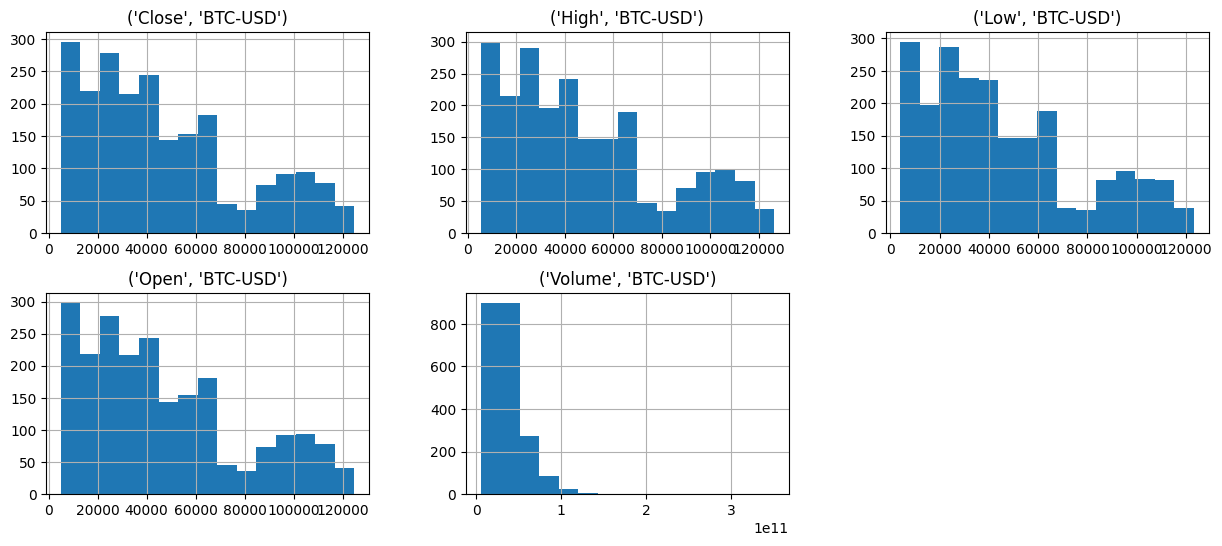

In [ ]:
# Make histogram of the data excluding the date column
main_df[main_df.columns[1:]].hist(bins=15, figsize=(15, 6), layout=(2, 3))
plt.show()

In [ ]:
# Check the first 5 rows of the dataframe
main_df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
0,2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
1,2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2,2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
3,2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
4,2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


In [ ]:
# Descriptive statistics
main_df.describe()

Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,2192,2192.000000,2192.000000,2192.000000,2192.000000,2.192000e+03
mean,2022-12-31 12:00:00,47194.854475,48086.662577,46184.172159,47160.060520,3.648228e+10
min,2020-01-01 00:00:00,4970.788086,5331.833984,4106.980957,5002.578125,5.331173e+09
25%,2021-07-01 18:00:00,22196.082031,22606.337402,21456.555176,22085.030273,2.221117e+10
50%,2022-12-31 12:00:00,39760.666016,40745.824219,38726.220703,39741.619141,3.198345e+10
75%,2024-07-01 06:00:00,64516.092773,65862.421875,63174.500977,64462.871094,4.537994e+10
max,2025-12-31 00:00:00,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11
std,NaN,31419.885554,31898.971101,30902.756650,31419.910267,2.162696e+10


In [ ]:
# Check for missing values
if main_df.isnull().sum().any() == 0:
    print('No missing values')
else:
    print('There are missing values')
    print('Number of missing values:', main_df.isnull().sum().any())

# If data has missing values, use KNN imputer to fill the missing values
# from sklearn.impute import KNNImputer
# imputer = KNNImputer(n_neighbors=2)
# main_df = pd.DataFrame(imputer.fit_transform(main_df), columns=main_df.columns)

# Check for missing values again

No missing values


In [ ]:
# Convert the date column to datetime
main_df['Date'] = pd.to_datetime(main_df['Date'])
print(main_df['Date'].dtype)
print(main_df['Date'].head())

datetime64[ns]
0   2020-01-01
1   2020-01-02
2   2020-01-03
3   2020-01-04
4   2020-01-05
Name: Date, dtype: datetime64[ns]


In [ ]:
# Rename df columns
main_df.columns = ['Date', 'Open', 'High', 'Low','Close','Volume']

# Plot Variables

In [ ]:
# Data_name list
data_names = ['Stock Open Price', 'Stock High Price', 'Stock Low Price', 'Stock Close Price']
# Month name list
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# Five years analyst

# Five year in different colors (total time)

In [ ]:
# Create a new DataFrame avg_5y_df
avg_5y_df = pd.DataFrame()
# Extract the 'Date' column from main_df
avg_5y_df['Date'] = main_df['Date']
# Calculate open and close price together and divide by 2 to get the average price for every day
avg_5y_df['Average'] = (main_df['Open'] + main_df['Close']) / 2

In [ ]:
# 1. Dynamically generate years from our previous variables
years = list(range(start_year, end_year + 1))

# 2. Use Plotly's built-in qualitative colors (handles up to 10 years safely)
colors = px.colors.qualitative.Plotly

# Create a figure
fig = go.Figure()

# Use lambda function to add traces
add_trace_lambda = lambda year_df, color, year_label: fig.add_trace(
    go.Scatter(x=np.array(year_df['Date']), y=year_df['Average'],
               mode='lines', name=str(year_label), line=dict(color=color))
)

# Loop through our dynamic years and colors
for i, year in enumerate(years):
    year_df = avg_5y_df[avg_5y_df['Date'].dt.year == year]

    # Safety check: Only add the trace if the dataframe actually has data for this year
    if not year_df.empty:
        # Use modulo (%) to cycle colors safely just in case you chart more than 10 years
        color = colors[i % len(colors)]
        add_trace_lambda(year_df, color, year)

# 3. Dynamic Title Update
fig.update_layout(
    title=f'Stock Analyst Chart of Bitcoin ({start_year}-{end_year}) Mean Values',
    xaxis_title='Date',
    yaxis_title='Average Price (USD)',
    template='plotly_dark'
)

# Show hover for all values by line
fig.update_traces(hoverinfo='y', hovertemplate='Average: $%{y:.2f}')

# Add range slider (You had this twice in your original code, so I combined it!)
fig.update_layout(xaxis=dict(rangeslider=dict(visible=True)))

# --- DYNAMIC HALVING DATES ---
# List of known halving dates
halving_dates = [dt.datetime(2020, 5, 11), dt.datetime(2024, 4, 19), dt.datetime(2028, 3, 1)] # Added 2024 and estimated 2028

# Loop through and only plot the ones that fit inside our current dynamic timeframe
for h_date in halving_dates:
    if h_date.year >= start_year and h_date.year <= end_year:
        fig.add_shape(type="line", x0=h_date, y0=0, x1=h_date, y1=100000,
                      line=dict(color="red", width=1, dash="dash"))
        fig.add_annotation(x=h_date, y=100000, text=f"Halving ({h_date.year})",
                           showarrow=True, arrowhead=1, arrowcolor='red')

# Show the chart
fig.show()

# Five year in different colors (monthly)

In [ ]:
# Set 'Date' column as the index
avg_5y_df.set_index('Date', inplace=True)

# Extract year for coloring
avg_5y_df['year'] = avg_5y_df.index.year

# Create a figure
fig = go.Figure()

# Iterate over each year and add a trace for each
for year, data in avg_5y_df.groupby('year'):
    # Group by month and day, and calculate the mean
    data['month_day'] = data.index.strftime('%m-%d')
    grouped = data.groupby('month_day').mean()

    # Extract month for x-axis labels
    grouped['month'] = grouped.index.str[:2]

    # Aggregate by month and calculate the mean
    grouped_by_month = grouped.groupby('month').mean()

    # Add a trace to the figure for this year
    fig.add_trace(go.Scatter(x=grouped_by_month.index, y=grouped_by_month['Average'], mode='lines', name=f'Average {year}'))

# Update the layout
fig.update_layout(title='Stock Analyst Chart of Bitcoin (Jan-Dec) mean values',
                  xaxis_title='Month',
                  yaxis_title='Average',
                  template='plotly_dark',
                  legend_title='Year')

# Show hover for all values by line
fig.update_traces(hoverinfo='y', hovertemplate='Average: $%{y:.2f}')

fig.show()

# Five years analyst overall

In [ ]:
# Copy the main_df and drop 'Adj Close' and 'Volume' safely
# Using errors='ignore' prevents crashes if yfinance ever renames these columns
overall_5y = main_df.drop(['Adj Close', 'Volume'], axis=1, errors='ignore').copy()

# Grouping data by day to ensure a continuous timeline, filling any missing gaps
daily_data = overall_5y.resample('D', on='Date').mean().shift(freq=pd.DateOffset(days=-1)).ffill()

# Convert index to array for x-axis
date_array = np.array(daily_data.index)

# Create a figure
fig = go.Figure()

# Add traces to the figure
fig.add_trace(go.Scatter(x=date_array, y=daily_data['Open'], mode='lines', name='Open'))
fig.add_trace(go.Scatter(x=date_array, y=daily_data['Close'], mode='lines', name='Close'))
fig.add_trace(go.Scatter(x=date_array, y=daily_data['High'], mode='lines', name='High'))
fig.add_trace(go.Scatter(x=date_array, y=daily_data['Low'], mode='lines', name='Low'))

# Update x-axis layout with rangeselector
fig.update_xaxes(rangeselector=dict(
    buttons=list([
        dict(count=1, label="1m", step="month", stepmode="backward"),
        dict(count=3, label="quarter", step="month", stepmode="backward"),
        dict(count=6, label="6m", step="month", stepmode="backward"),
        dict(count=1, label="1y", step="year", stepmode="backward"),
        dict(step="all")
    ]),
    bgcolor='gray'
))

# Show values on hover
fig.update_traces(hoverinfo='y', hovertemplate='Price: $%{y:.2f}')

# --- DYNAMIC LAYOUT UPDATES ---
fig.update_layout(
    title=f'Stock Analyst Chart of Bitcoin ({start_year}-{end_year})', # Dynamic years
    xaxis_title='Date', # Changed from 'Month' since data is daily
    yaxis_title='Stock Price (USD)',
    template='plotly_dark',
    height=600,
    width=1000,
    xaxis=dict(rangeslider=dict(visible=True)) # Consolidated your two layout calls into one
)

# --- DYNAMIC HALVING DATES & AUTO-SCALING ---
# Calculate the absolute highest price in the dataset to properly scale the halving line
max_price = daily_data['High'].max()
line_height = max_price * 1.05 # Draw the line 5% higher than the max price

# List of known halving dates
halving_dates = [dt.datetime(2020, 5, 11), dt.datetime(2024, 4, 19), dt.datetime(2028, 3, 1)]

# Loop through and only plot the halving events that fall within our active timeframe
for h_date in halving_dates:
    if h_date.year >= start_year and h_date.year <= end_year:
        # Add dashed line using dynamic height
        fig.add_shape(type="line", x0=h_date, y0=0, x1=h_date, y1=line_height,
                      line=dict(color="red", width=1, dash="dash"))
        # Add annotation using dynamic height
        fig.add_annotation(x=h_date, y=line_height, text=f"Halving ({h_date.year})",
                           showarrow=True, arrowhead=1, arrowcolor='red')

# Show the chart
fig.show()

# Combine google search trends data with stock price data

In [ ]:
# 1. Initialize Google Trends API connection
pytrends = TrendReq(hl='en-US', tz=360)

# 2. Build the exact timeframe string pytrends requires (Format: 'YYYY-MM-DD YYYY-MM-DD')
# We use the start_date and end_year variables from the previous step
timeframe_str = f"{start_date} {end_year}-12-31"
print(f"Fetching Worldwide Google Trends data for 'Bitcoin' from {timeframe_str}...")

# 3. Fetch the data
pytrends.build_payload(kw_list=['Bitcoin'], timeframe=timeframe_str, geo='')
df_BTC_ST = pytrends.interest_over_time()

# 4. Format the DataFrame to perfectly match your old CSV structure
if not df_BTC_ST.empty:
    # Drop the extra 'isPartial' column pytrends includes
    df_BTC_ST = df_BTC_ST.drop(columns=['isPartial'])

    # Reset index so 'date' becomes a standard column
    df_BTC_ST.reset_index(inplace=True)

    # Rename columns so the rest of your visualization code doesn't break!
    df_BTC_ST.rename(columns={'date': 'Month', 'Bitcoin': 'Bitcoin: (Worldwide)'}, inplace=True)

    # Ensure correct data types (pytrends usually handles this, but good to be safe)
    df_BTC_ST['Month'] = pd.to_datetime(df_BTC_ST['Month'])
    df_BTC_ST['Bitcoin: (Worldwide)'] = pd.to_numeric(df_BTC_ST['Bitcoin: (Worldwide)'], errors='coerce')

Fetching Worldwide Google Trends data for 'Bitcoin' from 2020-01-01 2025-12-31...


In [ ]:
# --- UPDATING THE FILTER MASK ---

# Note: Because we passed the exact dynamic timeframe to pytrends above,
# it only returns data for those dates anyway! But if you still want to apply
# the mask explicitly, here is how to make it dynamic:

mask_start = f"{start_year}-01-01"
mask_end = f"{end_year}-12-31"

# Create a mask to filter rows using our dynamic variables
mask = (df_BTC_ST['Month'] >= mask_start) & (df_BTC_ST['Month'] <= mask_end)

# Apply the mask to filter rows
df_filtered_BTC = df_BTC_ST.loc[mask]

# Reset the index of the filtered DataFrame
df_filtered_BTC = df_filtered_BTC.reset_index(drop=True)

print("Google Trends data successfully loaded and filtered!")

Google Trends data successfully loaded and filtered!


In [ ]:
# Handling missing values
if df_filtered_BTC.isnull().sum().any() > 0:
    print('There are missing values')
    print('Number of missing values:', df_BTC_ST.isnull().sum().sum())
else:
    print('No missing values')

No missing values


In [ ]:

# Conver Bitcoin: (Worldwide) column name to Search(0-100)
df_filtered_BTC = df_filtered_BTC.rename(columns={'Bitcoin: (Worldwide)': 'Search(0-100)'})
# Print the number of rows in the filtered DataFrame
print(f"Number of rows in filtered DataFrame: {len(df_filtered_BTC)}")

Number of rows in filtered DataFrame: 72


In [ ]:
# Create copy of main_df and drop
bitcoin_monthly_df = main_df.copy()
# Resample the data to monthly
bitcoin_monthly_df = bitcoin_monthly_df.resample('M', on='Date').mean().reset_index()
# Calculate the average of open and close to create a new 'Average' column
bitcoin_monthly_df['Average'] = (bitcoin_monthly_df['Open'] + bitcoin_monthly_df['Close']) / 2
# Print the number of the rows in the resulting DataFrame
print(f'Number of rows in the resulting DataFrame: {len(bitcoin_monthly_df)}')
# Display the first few rows of the resulting DataFrame


Number of rows in the resulting DataFrame: 72


/tmp/ipykernel_5443/2095882379.py:4: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



In [ ]:
# Create subplots with shared x-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Adding Bitcoin stock price data to the first y-axis
fig.add_trace(go.Scatter(x=bitcoin_monthly_df['Date'], y=bitcoin_monthly_df['Average'], mode='lines', name='Stock Price', line=dict(color='blue')))

# Adding Bitcoin search trend data to the secondary y-axis
fig.add_trace(go.Scatter(x=df_filtered_BTC['Month'], y=df_filtered_BTC['Search(0-100)'], mode='lines', name='Search Trend', line=dict(color='yellow')), secondary_y=True)

# Update the layout, title, legend, and x-axis
fig.update_layout(title='Bitcoin Stock Price and Search Trend Comparison',
                  xaxis_title='Month',
                  template='plotly_dark',
                  legend=dict(title='Stock Price', orientation='h', y=1, x=0, xanchor='left', yanchor='bottom'))

# Show range slider
fig.update_layout(xaxis=dict(rangeslider=dict(visible=True)))

# Show hover for stock price
fig.update_traces(hoverinfo='y', hovertemplate='Stock Price: $%{y:.2f}')

# Show hover for search trend
fig.update_traces(secondary_y=True, hoverinfo='y', hovertemplate='Search trend: %{y:.0f}/100')

# Set y-axis labels
fig.update_yaxes(title_text='Bitcoin Stock Price (avg)', showgrid=False, secondary_y=False)
fig.update_yaxes(title_text='Search Trend', showgrid=False, secondary_y=True)

# Add date line for special date
bitcoin_halving_date = dt.datetime(2020, 5, 11)

# Add dashed line and value name
fig.add_shape(type="line", x0=bitcoin_halving_date, y0=0, x1=bitcoin_halving_date, y1=100000, line=dict(color="red", width=2, dash="dash"))
fig.add_annotation(x=bitcoin_halving_date, y=8590, text="Bitcoin Halving $ 8950",xanchor='right', showarrow=True, arrowhead=1,arrowcolor='red')

# Make the figure larger
fig.update_layout(height=600, width=1200)

# Show the figure
fig.show()

# Check the search trend data and stock data
Stock volume vs search trend

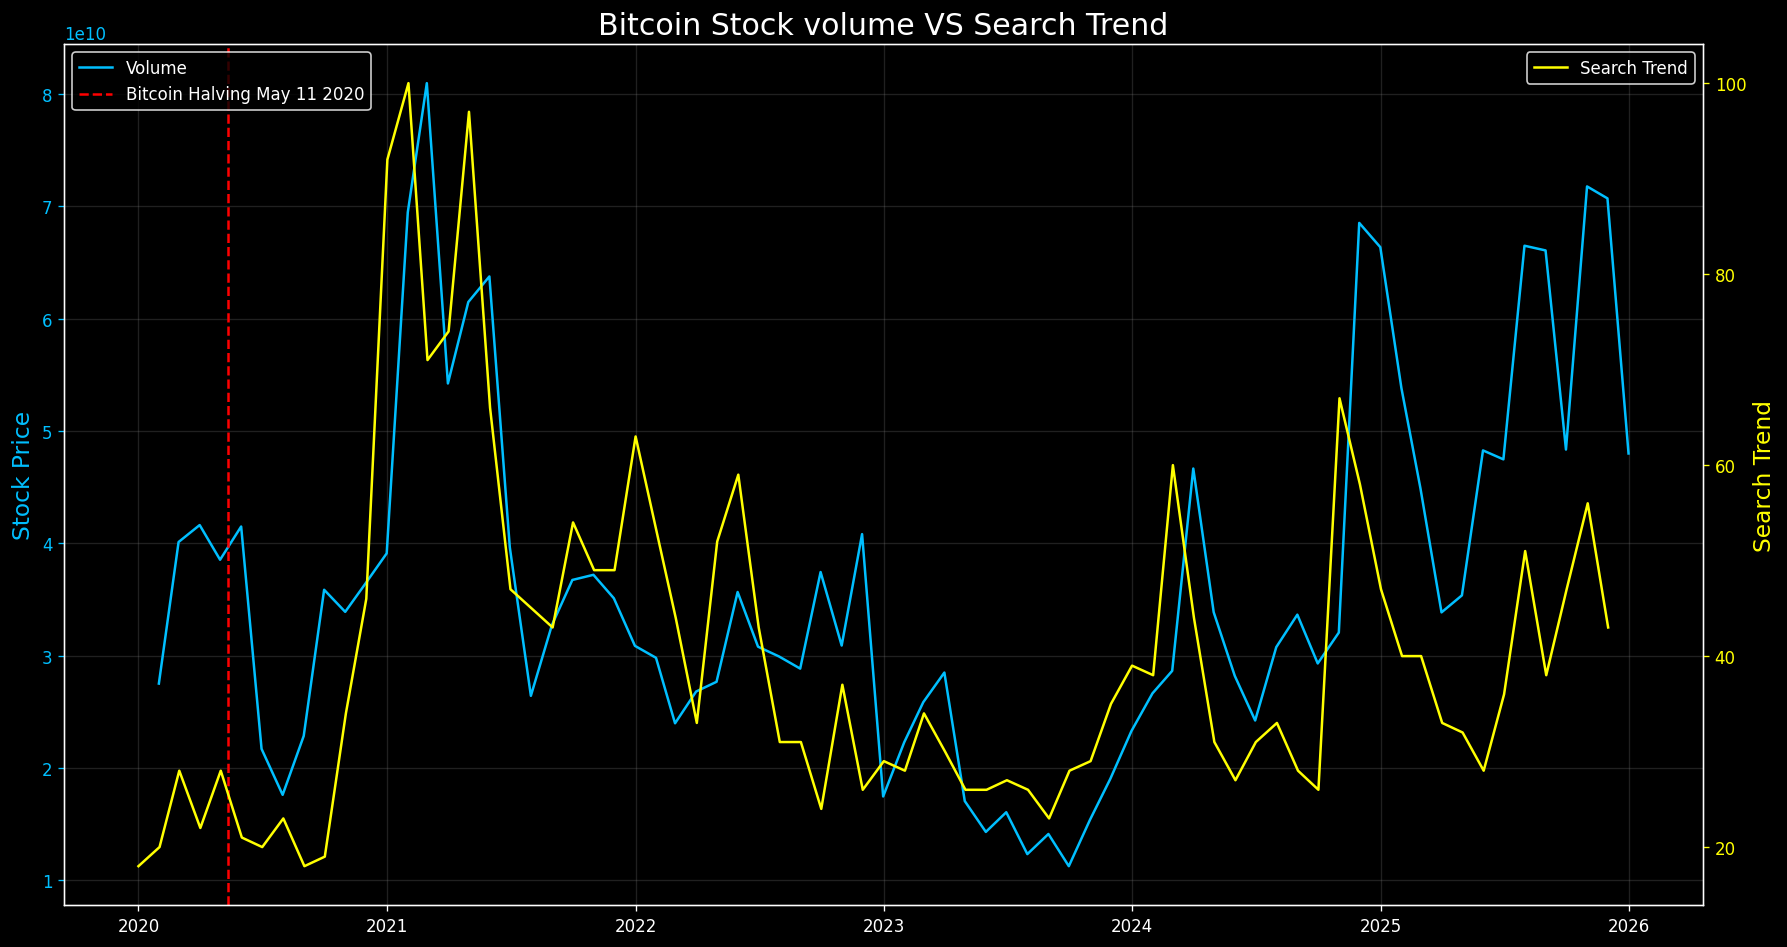

In [ ]:
# Plot stock volume vs search trend
# Using matplotlib

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(15, 8), dpi=120)

ax1 = plt.gca()
ax2 = ax1.twinx()

# ---- Dark background ----
plt.gcf().patch.set_facecolor('black')   # whole figure background
ax1.set_facecolor('black')               # main axes background
ax2.set_facecolor('black')               # twinx axes background

# ---- Title + x ticks ----
plt.title('Bitcoin Stock volume VS Search Trend', fontsize=18, color='white')
plt.xticks(rotation=45, fontsize=14, color='white')

# ---- Date tick locators/formatters ----
years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%Y')

ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)

# ---- Labels ----
ax1.set_ylabel('Stock Price', color='deepskyblue', fontsize=14)
ax2.set_ylabel('Search Trend', color='yellow', fontsize=14)

# ---- Tick colors ----
ax1.tick_params(axis='x', colors='white')
ax1.tick_params(axis='y', colors='deepskyblue')
ax2.tick_params(axis='y', colors='yellow')

# Optional: make spines visible on dark background
for sp in ax1.spines.values():
    sp.set_color('white')
for sp in ax2.spines.values():
    sp.set_color('white')

# Optional: subtle grid
ax1.grid(True, color='gray', alpha=0.25)

# ---- Plot lines ----
ax1.plot(
    bitcoin_monthly_df['Date'],
    bitcoin_monthly_df['Volume'],
    color='deepskyblue',
    label='Volume'
)

ax2.plot(
    df_filtered_BTC['Month'],
    df_filtered_BTC['Search(0-100)'],
    color='yellow',
    label='Search Trend'
)

# ---- Vertical marker ----
ax1.axvline(
    x=bitcoin_halving_date,
    color='red',
    linestyle='--',
    label='Bitcoin Halving May 11 2020'
)

# ---- Legends (make legend boxes dark too) ----
leg1 = ax1.legend(loc='upper left', facecolor='black', edgecolor='white')
leg2 = ax2.legend(loc='upper right', facecolor='black', edgecolor='white')
for t in leg1.get_texts():
    t.set_color('white')
for t in leg2.get_texts():
    t.set_color('white')

plt.tight_layout()
plt.show()

# END OF THE ANALYSIS